![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

Hier sind die verschiedenen **Logiken für die Datenübergabe** in Pandas und Matplotlib.

---

## 🔹 **1. Direktes Plotten mit Pandas `.plot()`**
Pandas erlaubt das direkte Plotten eines DataFrames oder einer Series mit `df.plot()`.

### ✅ **Variante 1: Automatische Achsenwahl**
Falls keine `x`-Achse explizit angegeben wird, nimmt Pandas automatisch den **Index**.

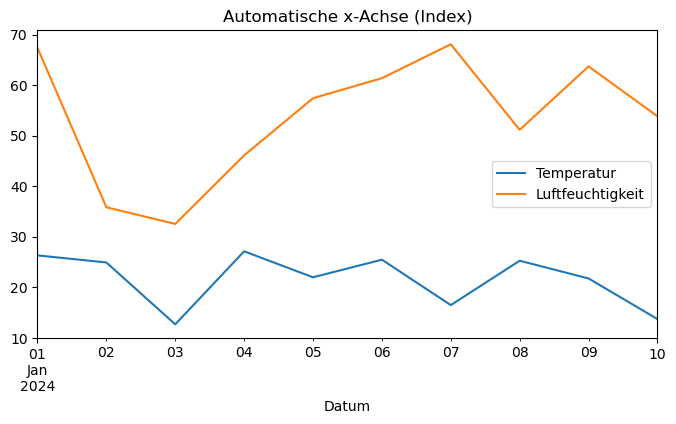

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dummy-Daten
df = pd.DataFrame(
    {
        "Datum": pd.date_range(start="2024-01-01", periods=10, freq="D"),
        "Temperatur": np.random.normal(20, 5, 10),
        "Luftfeuchtigkeit": np.random.uniform(30, 70, 10),
    }
)

df.set_index("Datum", inplace=True)  # Datum als Index setzen

# Direktes Plotten (Index wird als x-Achse verwendet)
df.plot(figsize=(8, 4))
plt.title("Automatische x-Achse (Index)")
plt.show()

➡ **Hier wird `Datum` automatisch als `x`-Achse verwendet, weil es der Index ist.**

---

### ✅ **Variante 2: Explizite Angabe von `x` und `y`**
Falls `x` und `y` als Spalten angegeben werden sollen:

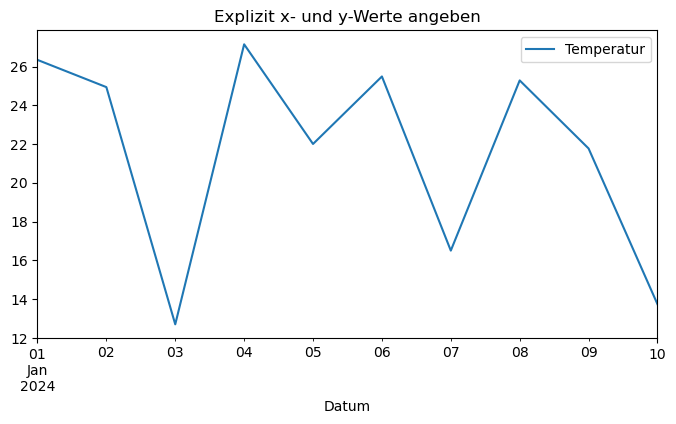

In [5]:
df.reset_index().plot(x="Datum", y="Temperatur", kind="line", figsize=(8, 4))
plt.title("Explizit x- und y-Werte angeben")
plt.show()

➡ **Hier wird `Datum` als `x` gesetzt, auch wenn es nicht mehr der Index ist.**

---

### ✅ **Variante 3: Mehrere y-Werte gleichzeitig plotten**
Falls mehrere Spalten gemeinsam als `y` dargestellt werden sollen:

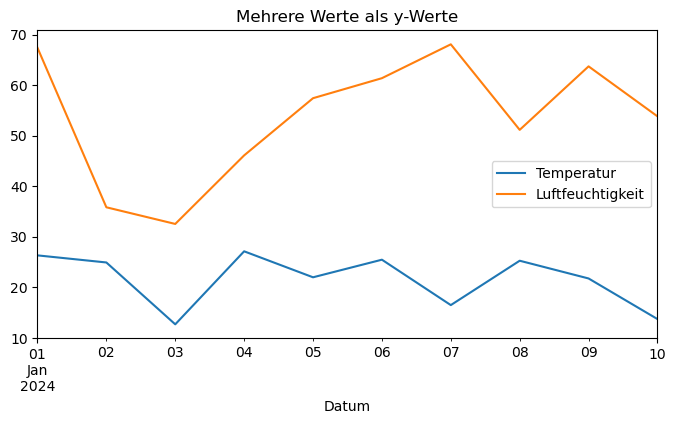

In [7]:
df.reset_index().plot(x="Datum", y=["Temperatur", "Luftfeuchtigkeit"], kind="line", figsize=(8, 4))
plt.title("Mehrere Werte als y-Werte")
plt.show()

➡ **Hier werden zwei Kurven für `Temperatur` und `Luftfeuchtigkeit` erstellt.**

---

## 🔹 **2. Matplotlib mit DataFrame als Quelle**
Pandas nutzt `matplotlib` im Hintergrund, aber du kannst den DataFrame auch explizit mit Matplotlib verwenden.

### ✅ **Variante 1: `plt.plot()` mit DataFrame-Spalten**
Hier übergibst du die Spalten als `x` und `y`.

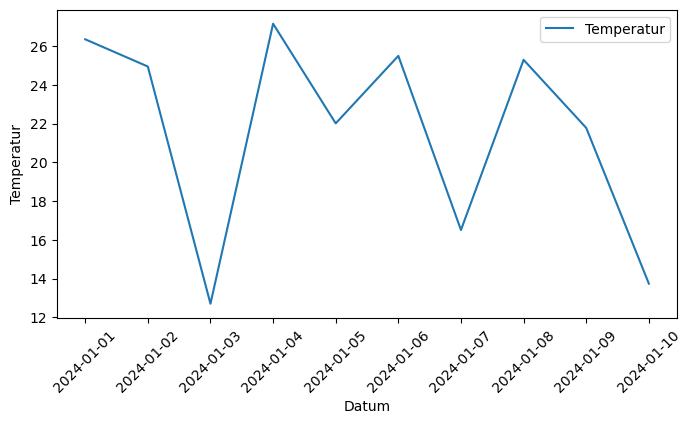

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df["Temperatur"], label="Temperatur")
plt.xlabel("Datum")
plt.ylabel("Temperatur")
plt.legend()
plt.xticks(rotation=45)
plt.show()

➡ **Hier werden `Datum` als `x` und `Temperatur` als `y` direkt verwendet.**

---

### ✅ **Variante 2: `plt.plot()` mit `df[]` Syntax**
Falls du eine Liste von `y`-Werten übergeben willst:

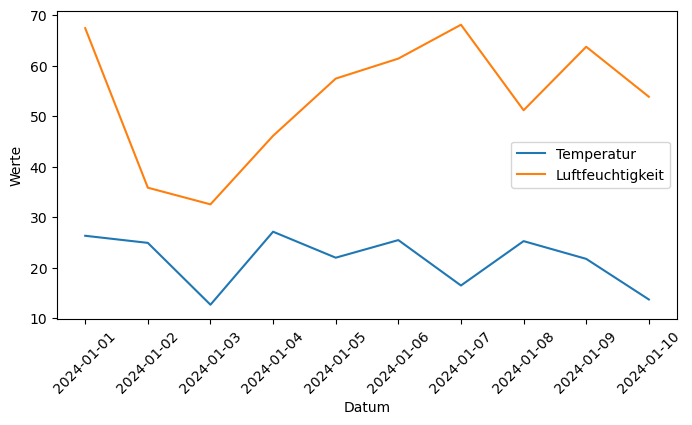

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df[["Temperatur", "Luftfeuchtigkeit"]])  # Mehrere Spalten
plt.xlabel("Datum")
plt.ylabel("Werte")
plt.legend(["Temperatur", "Luftfeuchtigkeit"])
plt.xticks(rotation=45)
plt.show()

➡ **Hier wird `df[["Temperatur", "Luftfeuchtigkeit"]]` übergeben, sodass beide Spalten geplottet werden.**

---

### ✅ **Variante 3: Mit `.values` oder `.to_numpy()`**
Falls du die Werte als **reine Arrays** extrahieren möchtest:

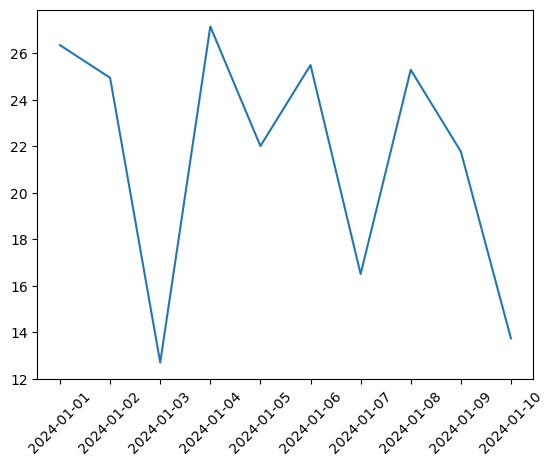

In [13]:
plt.plot(df.index.values, df["Temperatur"].values)
plt.xticks(rotation=45)
plt.show()

➡ **Hier wird der Index explizit in ein NumPy-Array umgewandelt.**

---

## 🔹 **3. Seaborn mit DataFrame als Quelle**
Seaborn arbeitet direkt mit DataFrames, ohne dass `x`- und `y`-Werte manuell extrahiert werden müssen.

### ✅ **Variante 1: `sns.lineplot()` mit `data=df`**

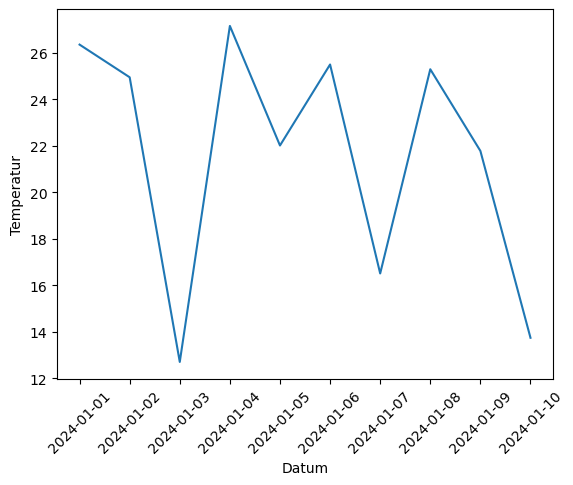

In [15]:
import seaborn as sns

sns.lineplot(x="Datum", y="Temperatur", data=df.reset_index())
plt.xticks(rotation=45)
plt.show()

➡ **Hier wird `data=df` genutzt, und `x="Datum"` sowie `y="Temperatur"` direkt übergeben.**

---




## **🎯 Wann welche Methode?**
| Methode  | Wann verwenden? |
|----------|----------------|
| `df.plot()`  | Einfach & schnell für Pandas DataFrames |
| `df.plot(x="Spalte1", y="Spalte2")` | Falls `x` und `y` nicht der Index sind |
| `plt.plot(df.index, df["Spalte"])` | Matplotlib direkt nutzen |
| `sns.lineplot(x="Spalte1", y="Spalte2", data=df)` | Falls Seaborn genutzt wird |

---

🔹 **Kurzfassung:**
- Wenn der **Index** als `x` genutzt werden soll → `df.plot()`
- Wenn `x` und `y` explizit definiert werden müssen → `df.plot(x="Spalte", y="Spalte")`
- Wenn du volle Kontrolle brauchst → `plt.plot(df["Spalte1"], df["Spalte2"])`
- Falls du **Seaborn** nutzt → `sns.lineplot(x="Spalte", y="Spalte", data=df)`

---

💡 **Fazit:**  
Du kannst mit Pandas `.plot()` direkt auf einen DataFrame oder eine Series zugreifen. Falls du `x` und `y` manuell setzen möchtest, brauchst du entweder `df.plot(x="Spalte", y="Spalte")` oder `plt.plot(df["Spalte1"], df["Spalte2"])`.  
Seaborn bietet `data=df`, sodass du direkt Spaltennamen nutzen kannst.

